# FEM Elements

## Finite-elements space of $H_0^1(0,1)$ with piece-wise linear functions 

In [1]:
using BandedMatrices, DifferentialEquations, Plots, LaTeXStrings

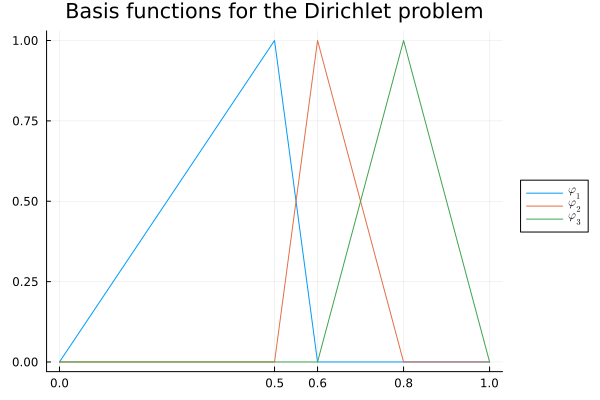

In [2]:
x = [0, 0.5, 0.6, 0.8, 1.0] # x[i+1] = x_i
N = length(x) - 1

# \phi_i are linear in each interval such that \phi_i(x_j) = \delta_{ij}
# \phi_0 and \phi_N are not include on the basis for Dirichlet boundary conditions
plot(title="Basis functions for the Dirichlet problem", legend=:outerright)
for k=2:N
    ek = zeros(N+1)
    ek[k] = 1.0  
    plot!(x, ek, label=latexstring("\\varphi_{$(k-1)}"), xticks=x)
end
plot!()

# Laplace's equation with Dirichlet boundary conditions
$$
    -\frac{d^2 u}{dx^2} = f \text{ in } (0,1) \qquad u(0) = u(1) = 0.
$$

In [3]:
function stiffness_matrix_piecewise_linear_Dirichlet(x::Vector)::BandedMatrix
    N = length(x) - 1
    # mass_upper_diag[i] = \int_{x_0}^{x_N} \phi_i' \phi_{i+1}'
    upper_diag = [-1 / (x[i+1] - x[i]) for i = 2:N-1]

    # mass_diag[i] = \int_{x_0}^{x_N} (\phi_i')^2
    diag = [1 / (x[i+1] - x[i]) + 1 / (x[i+2] - x[i+1]) for i = 1:N-1]

    K = BandedMatrix{Float64}(undef, (N - 1, N - 1), (1, 1))
    K[band(0)] = diag
    K[band(1)] = upper_diag
    K[band(-1)] = upper_diag
    return K
end

K = stiffness_matrix_piecewise_linear_Dirichlet(x)

3×3 BandedMatrix{Float64} with bandwidths (1, 1):
  12.0  -10.0    ⋅ 
 -10.0   15.0  -5.0
    ⋅    -5.0  10.0

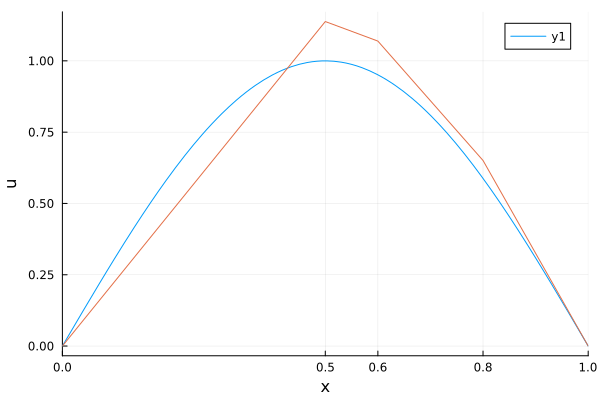

In [4]:
function FEMpiecewiselinearLaplaceDirichlet(x::Vector,f::Function)
    K = stiffness_matrix_piecewise_linear_Dirichlet(x)
    b = [(x[i+1] - x[i-1])/2 * f(x[i]) for i = 2:length(x)-1]
    U = K \ b
    return [0; U; 0]
end
f(x) = π^2 * sin(π*x)
u_exact(x) = sin(π*x)
plot(u_exact, xlims=(0,1))

x = [0, 0.5, 0.6, 0.8, 1.0] # x[i+1] = x_i
U = FEMpiecewiselinearLaplaceDirichlet(x,f)
plot!(x, U, xticks=x, label="", ylabel="u", xlabel="x")

### Convergence plot

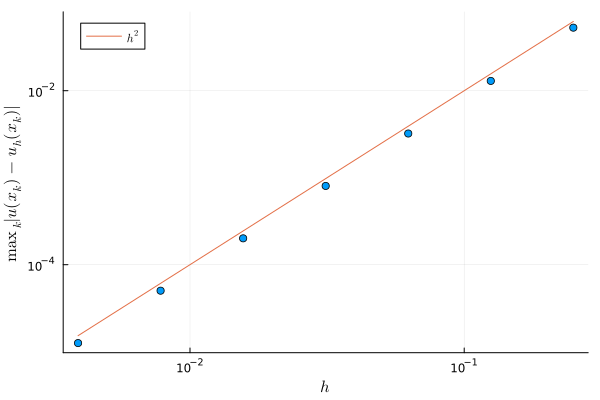

In [5]:
f(x) = π^2 * sin(π*x)
u_exact(x) = sin(π*x)

hs = 2.0 .^ collect(-2:-1:-8)
errors = zeros(length(hs))
for (i,h) in enumerate(hs)
    x = collect(0.:h:1.)
    U = FEMpiecewiselinearLaplaceDirichlet(x,f)
    errors[i] = maximum(abs.(u_exact.(x) - U ))
end

scatter(hs,errors, xscale=:log10, yscale=:log10, xlabel=L"h", ylabel=L"\max_k |u(x_k) - u_h(x_k)|", label="")
plot!(x->x^2, label=L"$h^2$")